In [42]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [92]:
df = pd.read_csv(r"C:\Users\rachi\Downloads\titanic.csv")
d1=df.copy()

In [93]:
df.shape

(891, 12)

In [94]:
df.isnull().sum()


PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [95]:
from sklearn.impute import SimpleImputer
si = SimpleImputer(strategy='mean')
df[['Age']]=si.fit_transform(df[['Age']])

In [96]:
s = SimpleImputer(strategy = 'most_frequent')
df[['Embarked']]=s.fit_transform(df[['Embarked']])

In [97]:
df=df.drop(['Cabin','Name','PassengerId'],axis=1)

In [98]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
for i in df.columns:
    if df[i].dtype=='object':
        df[i]=le.fit_transform(df[i])

<Axes: >

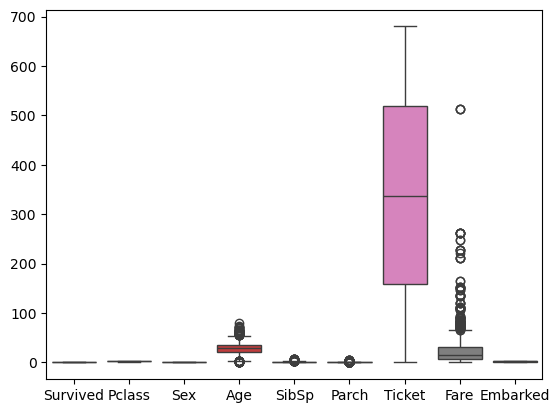

In [99]:
sns.boxplot(data=df.select_dtypes(include=['int64', 'float64']))

In [100]:
df.dtypes

Survived      int64
Pclass        int64
Sex           int64
Age         float64
SibSp         int64
Parch         int64
Ticket        int64
Fare        float64
Embarked      int64
dtype: object

In [101]:
from sklearn.preprocessing import StandardScaler
ss = StandardScaler()
scaled_data = ss.fit_transform(df)
df = pd.DataFrame(
    scaled_data,
    columns=df.columns
)
d = df[['Age','SibSp','Parch','Fare']]
for i in d:
    low = df[i].quantile(0.25)
    up = df[i].quantile(0.75)
    df[i]=df[i].clip(low,up)

<Axes: >

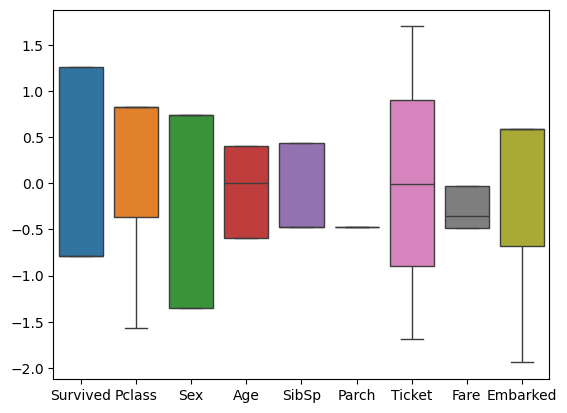

In [102]:
sns.boxplot(data=df.select_dtypes(include=['int64', 'float64']))

In [103]:
from sklearn.neighbors import KNeighborsClassifier
kn = KNeighborsClassifier(n_neighbors=5,metric='euclidean')


In [104]:
X= df.drop('Survived',axis=1)


In [105]:
y= d1['Survived']

In [106]:
from sklearn.model_selection import train_test_split
Xt,Xte,yt,yte=train_test_split(X,y,test_size=0.2,random_state=42)

In [107]:
kn.fit(Xt,yt)

,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'euclidean'
,metric_params,None
,n_jobs,None


In [108]:
yp=kn.predict(Xte)

In [109]:
from sklearn.metrics import classification_report as cr
print(cr(yte,yp))

              precision    recall  f1-score   support

           0       0.77      0.81      0.79       105
           1       0.71      0.65      0.68        74

    accuracy                           0.74       179
   macro avg       0.74      0.73      0.73       179
weighted avg       0.74      0.74      0.74       179

